In [8]:
#IMPORT LIBRARIES
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score


In [10]:
# LOAD DATASET
df = pd.read_csv("student performance.csv")

In [34]:
#SHOW DATASET
# SHOW FIRST 5 ROWS
print(df.head())

   student_id  weekly_self_study_hours  attendance_percentage  \
0           1                     18.5                   95.6   
1           2                     14.0                   80.0   
2           3                     19.5                   86.3   
3           4                     25.7                   70.2   
4           5                     13.4                   81.9   

   class_participation  total_score grade  
0                  3.8         97.9     A  
1                  2.5         83.9     B  
2                  5.3        100.0     A  
3                  7.0        100.0     A  
4                  6.9         92.0     A  


In [12]:
# DATASET INFORMATION
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 6 columns):
 #   Column                   Non-Null Count    Dtype  
---  ------                   --------------    -----  
 0   student_id               1000000 non-null  int64  
 1   weekly_self_study_hours  1000000 non-null  float64
 2   attendance_percentage    1000000 non-null  float64
 3   class_participation      1000000 non-null  float64
 4   total_score              1000000 non-null  float64
 5   grade                    1000000 non-null  object 
dtypes: float64(4), int64(1), object(1)
memory usage: 45.8+ MB


In [13]:
# CHECK MISSING VALUES
df.isnull().sum()

student_id                 0
weekly_self_study_hours    0
attendance_percentage      0
class_participation        0
total_score                0
grade                      0
dtype: int64

In [14]:
df.describe()

,student_id,weekly_self_study_hours,attendance_percentage,class_participation,total_score
count,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000
mean,500000.500000,15.029127,84.711046,5.985203,84.283845
std,288675.278933,6.899431,9.424143,1.956421,15.432969
min,1.000000,0.000000,50.000000,0.000000,9.400000
25%,250000.750000,10.300000,78.300000,4.700000,73.900000
50%,500000.500000,15.000000,85.000000,6.000000,87.500000
75%,750000.250000,19.700000,91.800000,7.300000,100.000000
max,1000000.000000,40.000000,100.000000,10.000000,100.000000


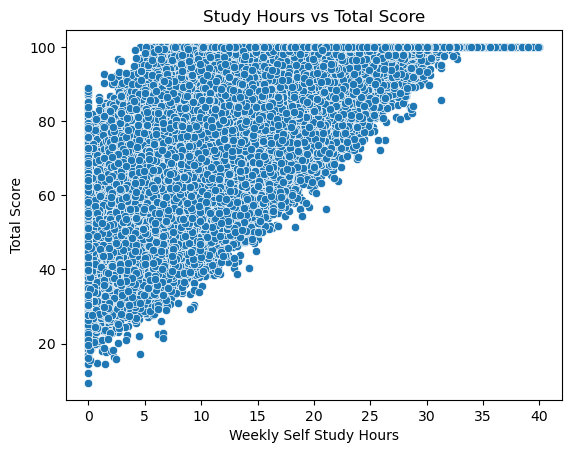

In [26]:
#  SCATTER PLOT
sns.scatterplot(
    x='weekly_self_study_hours',
    y='total_score',
    data=df
)

plt.title("Study Hours vs Total Score")
plt.xlabel("Weekly Self Study Hours")
plt.ylabel("Total Score")

plt.show()


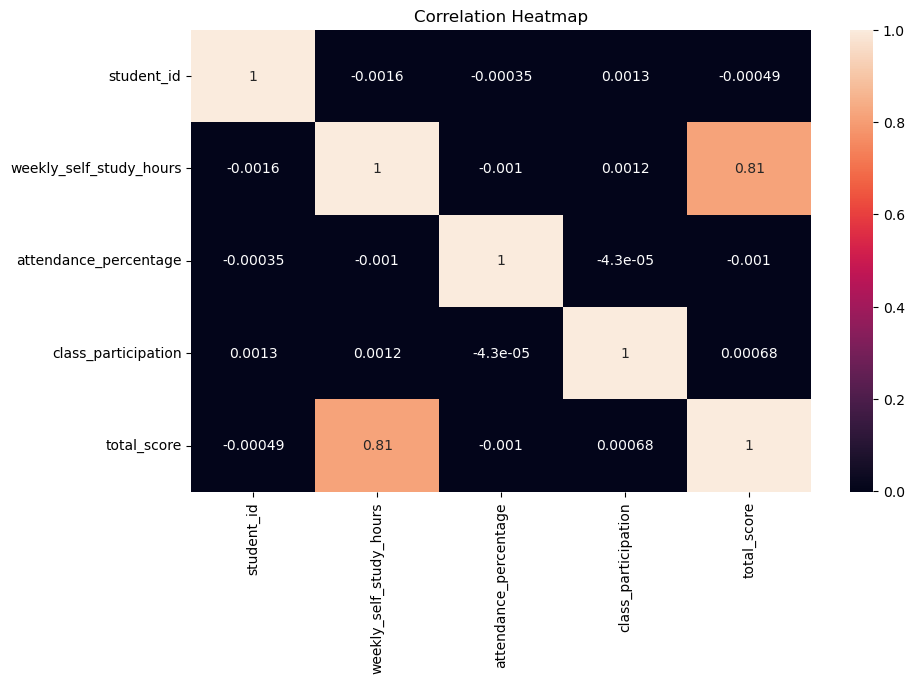

In [16]:
# HEATMAP
plt.figure(figsize=(10,6))

sns.heatmap(
    df.select_dtypes(include=['number']).corr(),
    annot=True
)

plt.title("Correlation Heatmap")

plt.show()



In [28]:
# SELECT FEATURES 
X = df[[
    'weekly_self_study_hours',
    'attendance_percentage',
    'class_participation'
]]
# SELECT TARGET
y = df['total_score']

In [29]:
# SPLIT DATASET
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [30]:
#  CREATE MODEL
model = LinearRegression()
# TRAIN MODEL
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [31]:
 # NEW STUDENT DATA
new_data = pd.DataFrame({
    'weekly_self_study_hours': [18],
    'attendance_percentage': [90],
    'class_participation': [7]
})

In [32]:
# PREDICT SCORE
prediction = model.predict(new_data)

print("Predicted Total Score:", round(prediction[0], 2))

Predicted Total Score: 89.67


In [33]:
#TEST DATA PREDICTION
y_pred = model.predict(X_test)

# MODEL ACCURACY
accuracy = r2_score(y_test, y_pred)
print("Model Accuracy:", round(accuracy, 2))

Model Accuracy: 0.66
